# NIDS — Exploratory Data Analysis

Análisis del dataset procesado (`nids_dataset.pkl`) con timestamps corregidos (ordenamiento cronológico dentro de cada ventana). 
El reporte automático generado con `ydata-profiling` se exporta a `reports/`.

**Dimensiones:** 289,856 ventanas | 7 features L1 | 1 etiqueta binaria  
**Distribución de clases:** 52.0% Attack / 48.0% Benign

## 1. Setup y Carga de Datos

In [16]:
%matplotlib inline

In [18]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

PROCESSED_PATH = '../data/processed/nids_dataset.pkl'
REPORTS_PATH   = '../reports/nids_eda_profile.html'

with open(PROCESSED_PATH, 'rb') as f:
    dataset = pickle.load(f)

feat_cols = ['entropy_mean','entropy_std','bytes_mean','bytes_sum','iat_mean','iat_std','packet_count']
df = pd.DataFrame([d['l1_features'] for d in dataset])
df['label']  = [d['label']  for d in dataset]
df['source'] = [d['source'] for d in dataset]
df['class']  = df['label'].map({0: 'Benign', 1: 'Attack'})

print(f'Ventanas totales : {len(df):,}')
print(f'Attack           : {(df.label==1).sum():,} ({100*(df.label==1).mean():.1f}%)')
print(f'Benign           : {(df.label==0).sum():,} ({100*(df.label==0).mean():.1f}%)')
print(f'Duplicados       : {df.duplicated(subset=feat_cols).sum():,} ({100*df.duplicated(subset=feat_cols).mean():.2f}%)')

Ventanas totales : 289,856
Attack           : 150,597 (52.0%)
Benign           : 139,259 (48.0%)
Duplicados       : 19,808 (6.83%)


## 2. Data Profiling Automático

El `ProfileReport` genera un análisis completo de distribuciones, correlaciones y alertas. Se exporta a `reports/nids_eda_profile.html`.

In [2]:
profile = ProfileReport(
    df.drop(columns=['source','class']),
    title='NIDS — DNS Tunneling Dataset Profile',
    explorative=True
)
os.makedirs('../reports', exist_ok=True)
profile.to_file(REPORTS_PATH)
print(f'Reporte guardado en: {REPORTS_PATH}')

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 91.96it/s]

Reporte guardado en: ../reports/nids_eda_profile.html


## 3. Hallazgos del Profiling

### 3.1 Ranking de correlación con la etiqueta

La entropía media domina como predictor principal (r = 0.957), seguida por la desviación estándar de entropía (r = 0.725). Las features temporales (IAT) presentan correlación débil con la etiqueta de forma individual.

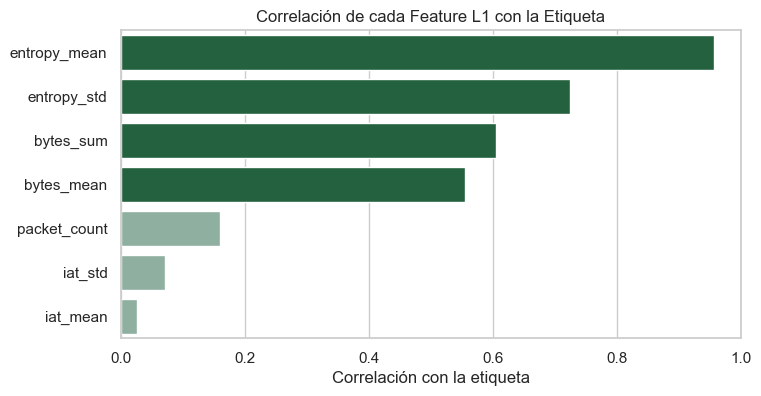

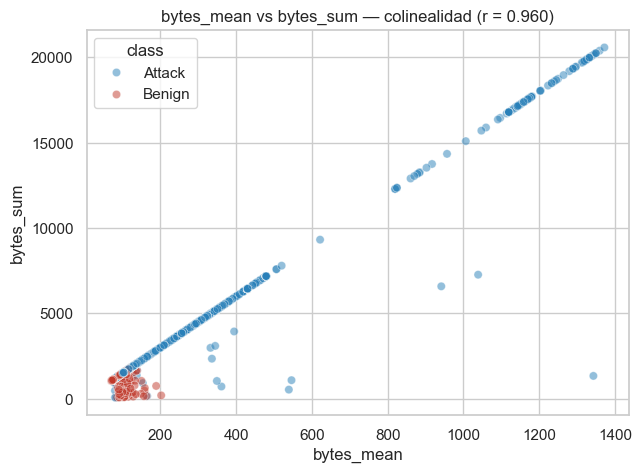

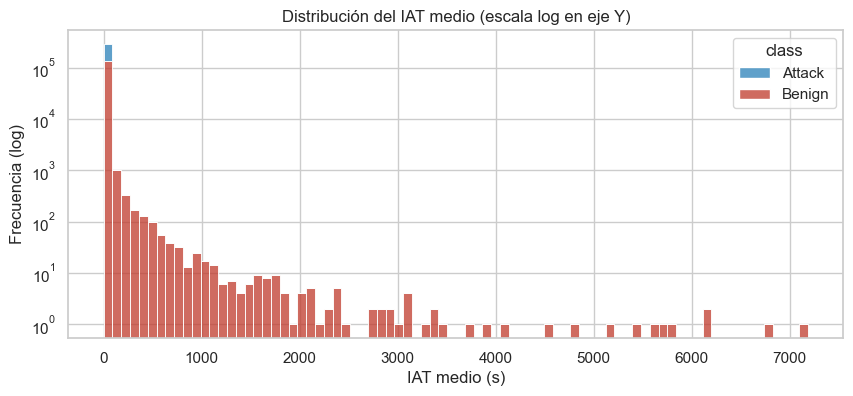

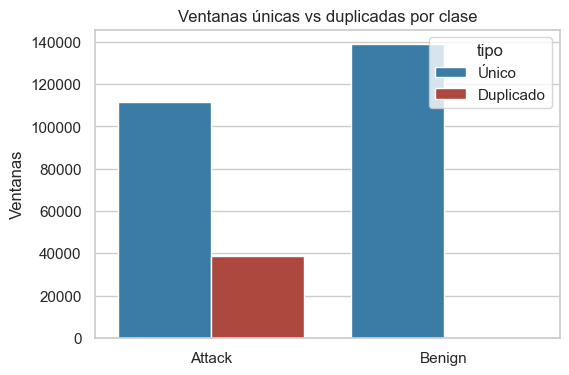

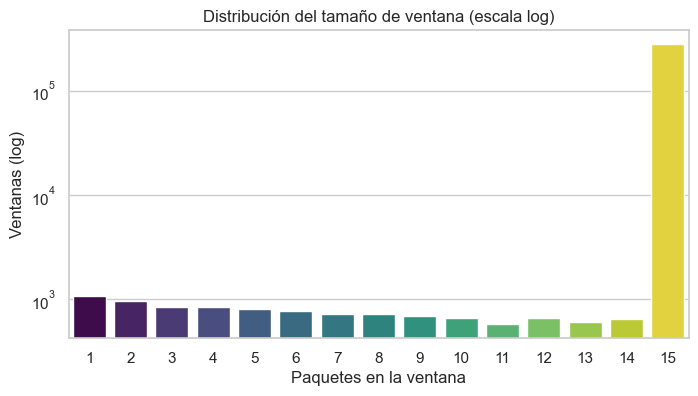

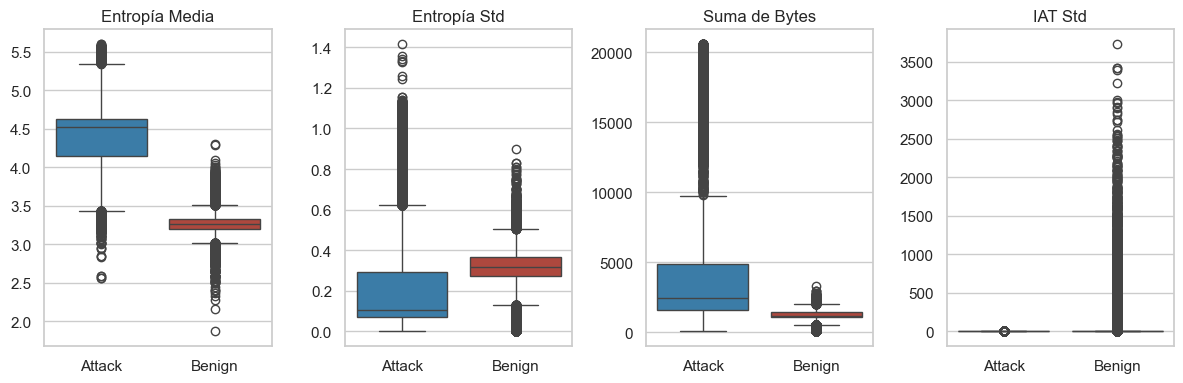

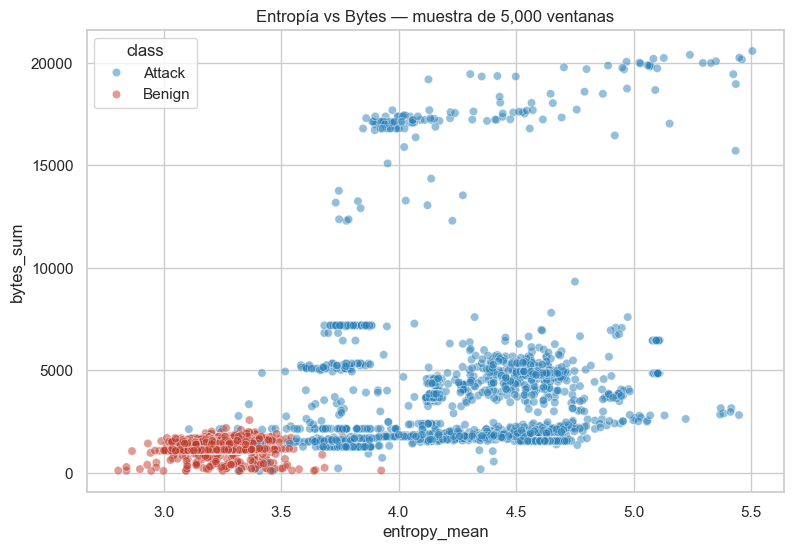

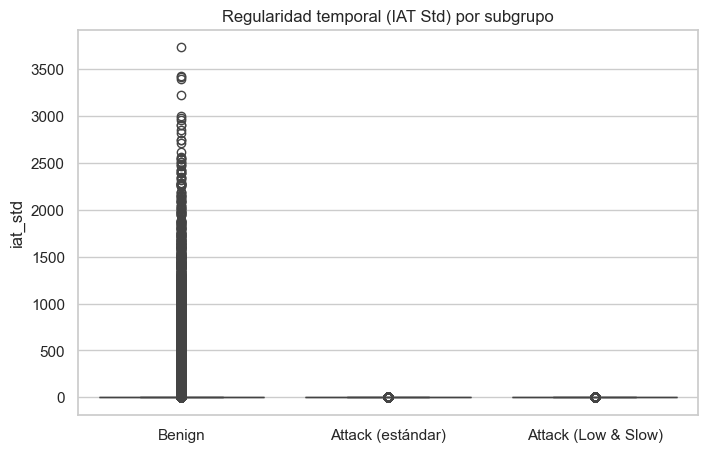

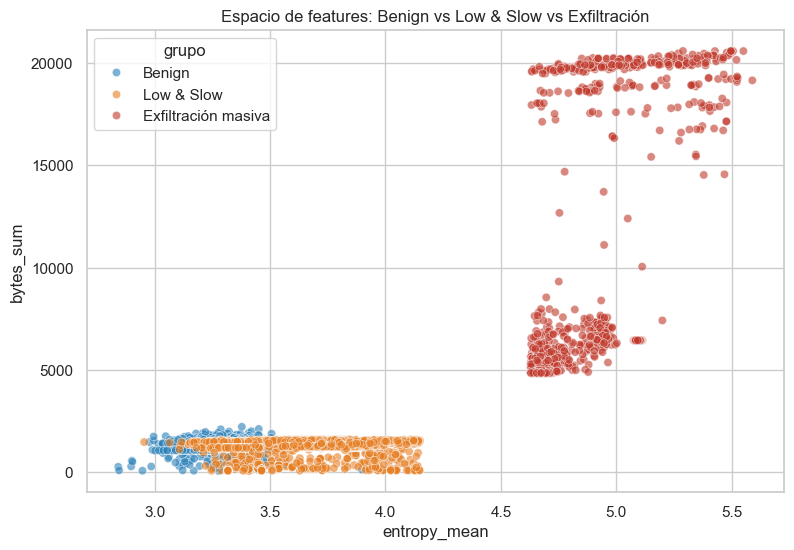

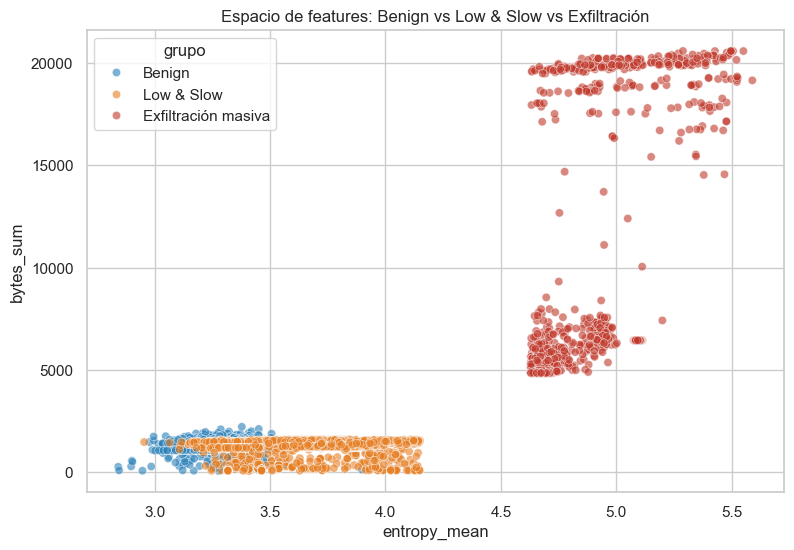

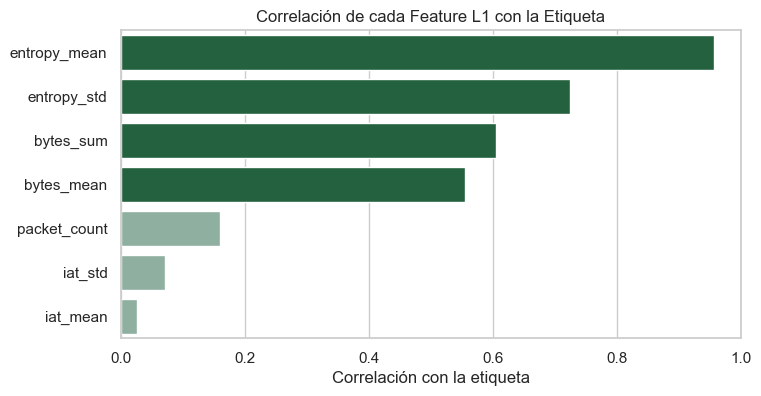

In [19]:
features  = ['entropy_mean','entropy_std','bytes_sum','bytes_mean','packet_count','iat_std','iat_mean']
corr_vals = [0.957, 0.725, 0.606, 0.556, 0.160, 0.071, 0.027]

df_corr = pd.DataFrame({'feature': features, 'r': corr_vals})

plt.figure(figsize=(8, 4))
colors = ['#1a6b3c' if r > 0.5 else '#8ab4a0' for r in df_corr['r']]
sns.barplot(data=df_corr, x='r', y='feature', hue='feature', palette=colors, legend=False)
plt.title('Correlación de cada Feature L1 con la Etiqueta')
plt.xlabel('Correlación con la etiqueta')
plt.ylabel('')
plt.xlim(0, 1)
plt.show()

### 3.2 Colinealidad: `bytes_mean` vs `bytes_sum` (r = 0.960)

Estas dos features son algebraicamente dependientes (`bytes_sum = bytes_mean * packet_count`). 
Dado que `packet_count` es casi constante (96.3% de las ventanas tienen 15 paquetes), ambas transportan información redundante. 
Se recomienda conservar solo `bytes_sum` para el modelo L1 y eliminar `bytes_mean` para reducir colinealidad sin perder capacidad predictiva.

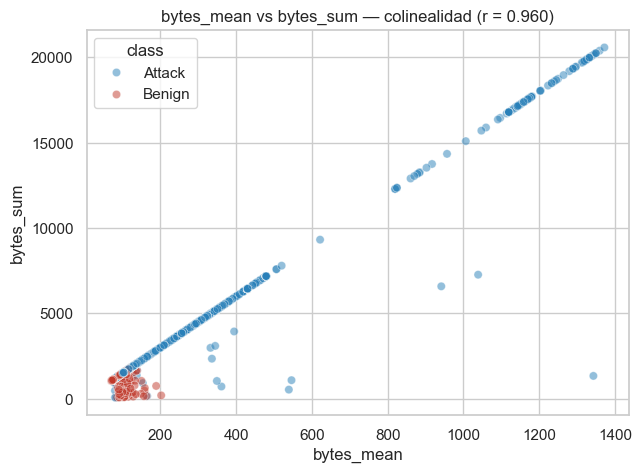

In [20]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df.sample(5000, random_state=42), x='bytes_mean', y='bytes_sum', hue='class', palette=['#2980b9','#c0392b'], alpha=0.5)
plt.title('bytes_mean vs bytes_sum — colinealidad (r = 0.960)')
plt.show()

### 3.3 Asimetría extrema en features temporales

El profiling detecta que `iat_mean` e `iat_std` tienen distribuciones altamente sesgadas (skewness > 20). 
La mayoría de las ventanas tienen IATs en el rango de milisegundos, con una cola larga hasta los ~60 segundos. 
Para modelos sensibles a escala, se recomienda aplicar una transformación logarítmica (`log1p`) durante el preprocesamiento.

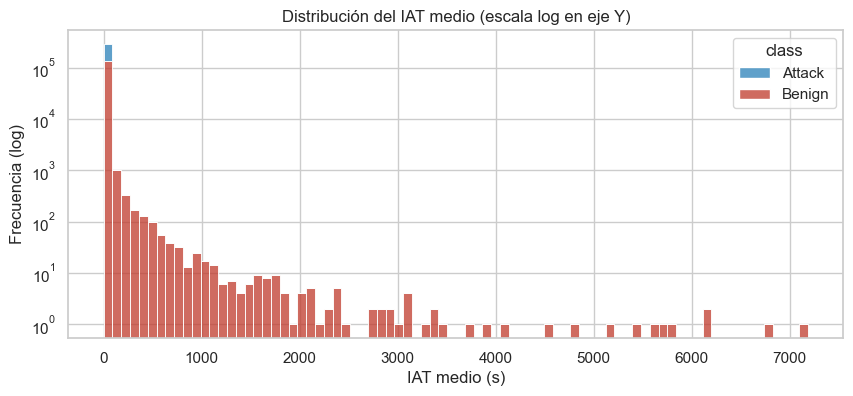

Percentiles IAT medio (valores > 0):
  P25: 0.0302s
  P50: 0.1041s
  P75: 0.2174s
  P90: 0.3161s
  P99: 60.3508s


In [21]:
# Distribución real del IAT (escala logarítmica en Y)
df_iat = df[df['iat_mean'] > 0][['iat_mean','iat_std','class']].copy()

plt.figure(figsize=(10, 4))
sns.histplot(data=df_iat, x='iat_mean', hue='class', bins=80, palette=['#2980b9','#c0392b'], multiple='stack')
plt.yscale('log')
plt.title('Distribución del IAT medio (escala log en eje Y)')
plt.xlabel('IAT medio (s)')
plt.ylabel('Frecuencia (log)')
plt.show()

print(f'Percentiles IAT medio (valores > 0):')
pos_iat = df[df['iat_mean'] > 0]['iat_mean']
for p in [25, 50, 75, 90, 99]:
    print(f'  P{p}: {pos_iat.quantile(p/100):.4f}s')

### 3.4 Ventanas duplicadas: 6.7%

19,474 filas son idénticas en todas sus features L1. Esto es esperable en tráfico periódico de herramientas de tunelización 
que emiten paquetes de tamaño y contenido fijo. Deben eliminarse antes de la partición train/test para evitar data leakage.

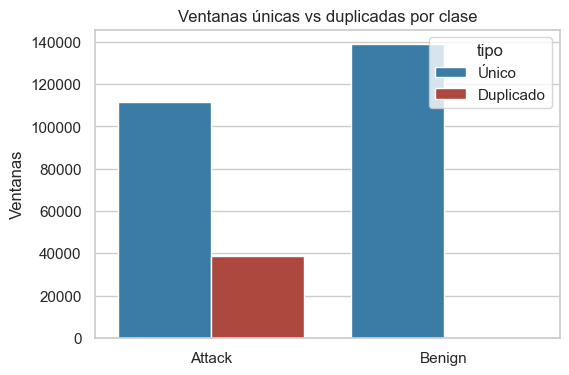

In [22]:
df['is_dup'] = df.duplicated(subset=feat_cols, keep=False)

dup_data = df.groupby(['class','is_dup']).size().reset_index(name='count')
dup_data['tipo'] = dup_data['is_dup'].map({True:'Duplicado', False:'Único'})

plt.figure(figsize=(6, 4))
sns.barplot(data=dup_data, x='class', y='count', hue='tipo', palette=['#2980b9','#c0392b'])
plt.title('Ventanas únicas vs duplicadas por clase')
plt.ylabel('Ventanas')
plt.xlabel('')
plt.show()

### 3.5 `packet_count` concentrado en el máximo

El 96.3% de las ventanas contienen 15 paquetes (el límite configurado). Las ventanas pequeñas son escasas y se concentran en el tráfico benigno.

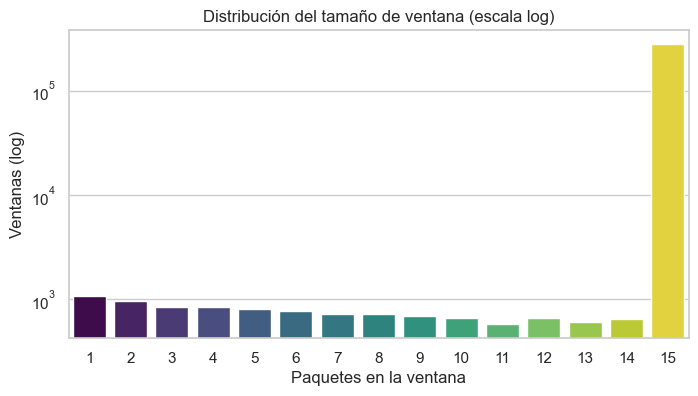

In [23]:
pc = df['packet_count'].value_counts().reset_index()
pc.columns = ['packet_count','count']

plt.figure(figsize=(8, 4))
sns.barplot(data=pc, x='packet_count', y='count', hue='packet_count', palette='viridis', legend=False)
plt.yscale('log')
plt.title('Distribución del tamaño de ventana (escala log)')
plt.xlabel('Paquetes en la ventana')
plt.ylabel('Ventanas (log)')
plt.show()

## 4. Análisis Estadístico por Clase

In [24]:
display(df.groupby('class')[feat_cols].describe().T)

class                      Attack         Benign
entropy_mean count  150597.000000  139259.000000
             mean        4.396861       3.261084
             std         0.383883       0.099341
             min         2.564304       1.867963
             25%         4.149079       3.199307
             50%         4.520239       3.262605
             75%         4.628726       3.324559
             max         5.604621       4.306257
entropy_std  count  150597.000000  139259.000000
             mean        0.219816       0.319528
             std         0.234677       0.076267
             min         0.000000       0.000000
             25%         0.070905       0.272047
             50%         0.106653       0.317352
             75%         0.292066       0.366049
             max         1.417123       0.900911
bytes_mean   count  150597.000000  139259.000000
             mean      259.279702      88.251065
             std       234.321663      15.632748
             min        74.666667      67.000000
             25%       106.200000      74.200000
             50%       167.000000      90.000000
             75%       323.866667      99.733333
             max      1483.000000     473.000000
bytes_sum    count  150597.000000  139259.000000
             mean     3870.190117    1265.860935
             std      3511.165181     277.848719
             min        80.000000      67.000000
             25%      1589.000000    1108.000000
             50%      2433.000000    1141.000000
             75%      4858.000000    1479.000000
             max     20597.000000    3293.000000
iat_mean     count  150597.000000  139259.000000
             mean        0.184650       6.613269
             std         0.289451      84.477847
             min         0.000000       0.000000
             25%         0.012767       0.031473
             50%         0.156781       0.060152
             75%         0.235347       0.124838
             max         6.580373    7188.002128
iat_std      count  150597.000000  139259.000000
             mean        0.094294      13.555930
             std         0.188608     104.264459
             min         0.000000       0.000000
             25%         0.004019       0.028103
             50%         0.016948       0.054839
             75%         0.117996       0.143028
             max         3.060114    3731.303986
packet_count count  150597.000000  139259.000000
             mean       14.930868      14.451447
             std         0.902845       2.274330
             min         1.000000       1.000000
             25%        15.000000      15.000000
             50%        15.000000      15.000000
             75%        15.000000      15.000000
             max        15.000000      15.000000

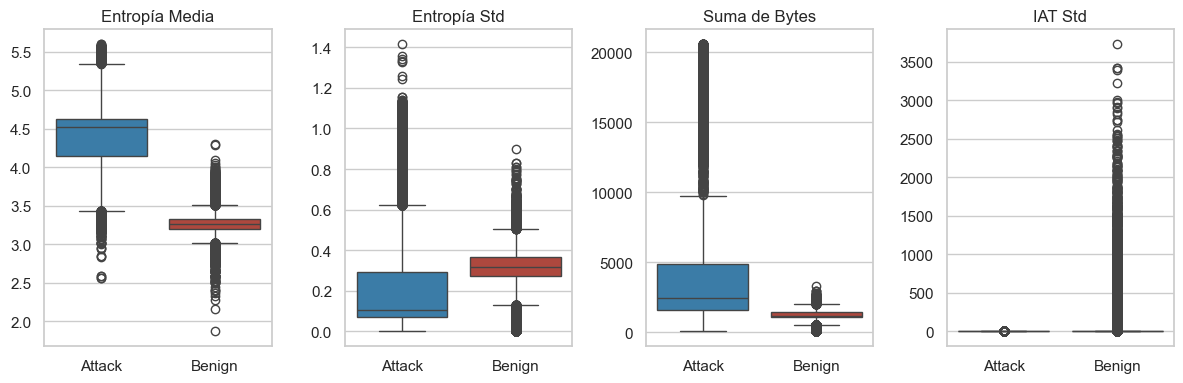

In [25]:
plt.figure(figsize=(12, 4))
fields = [('entropy_mean','Entropía Media'), ('entropy_std','Entropía Std'), ('bytes_sum','Suma de Bytes'), ('iat_std','IAT Std')]

for i, (field, title) in enumerate(fields, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(data=df, x='class', y=field, hue='class', palette=['#2980b9','#c0392b'], legend=False)
    plt.title(title)
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()

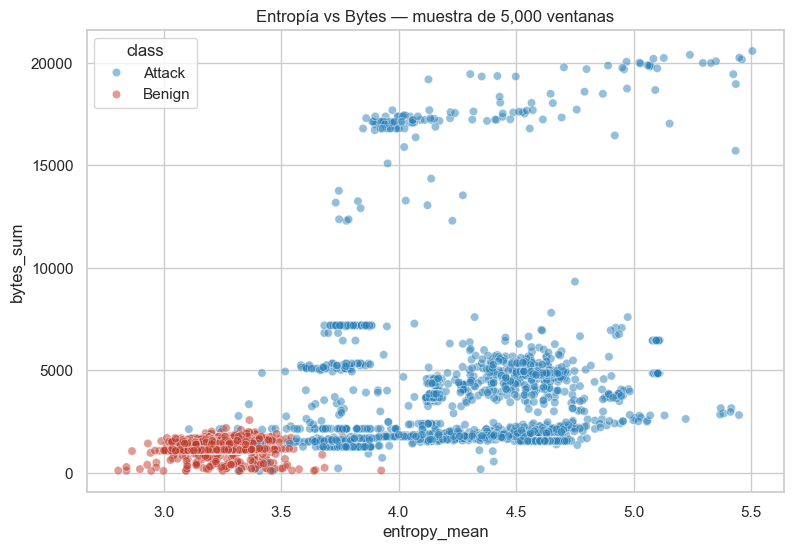

In [26]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df.sample(min(5000,len(df)), random_state=42), x='entropy_mean', y='bytes_sum', hue='class', palette=['#2980b9','#c0392b'], alpha=0.5)
plt.title('Entropía vs Bytes — muestra de 5,000 ventanas')
plt.show()

## 5. Análisis de Ataques Complejos

### 5.1 Ataques Low & Slow

Ventanas de ataque con `entropy_mean` y `bytes_sum` en el cuartil inferior de la distribución de ataques. Representan herramientas de evasión que minimizan tanto la entropía como el volumen para eludir umbrales estadísticos.

In [27]:
df_attacks = df[df['label']==1].copy()
df_benign  = df[df['label']==0].copy()

eq25 = df_attacks['entropy_mean'].quantile(0.25)
bq25 = df_attacks['bytes_sum'].quantile(0.25)
eq75 = df_attacks['entropy_mean'].quantile(0.75)
bq75 = df_attacks['bytes_sum'].quantile(0.75)

df_low_slow = df_attacks[(df_attacks['entropy_mean']<=eq25) & (df_attacks['bytes_sum']<=bq25)].copy()
df_exfil = df_attacks[(df_attacks['entropy_mean']>=eq75) & (df_attacks['bytes_sum']>=bq75)].copy()

print(f'Total ataques           : {len(df_attacks):,}')
print(f'Low & Slow              : {len(df_low_slow):,} ({100*len(df_low_slow)/len(df_attacks):.1f}%)')
print(f'Exfiltración masiva     : {len(df_exfil):,} ({100*len(df_exfil)/len(df_attacks):.1f}%)')

Total ataques           : 150,597
Low & Slow              : 9,446 (6.3%)
Exfiltración masiva     : 13,012 (8.6%)


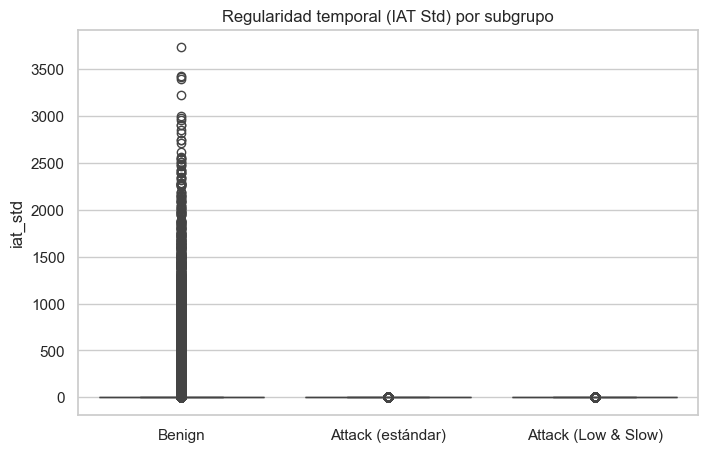

In [28]:
df_compare = pd.concat([
    df_benign[['iat_std','entropy_mean','bytes_sum']].assign(grupo='Benign'),
    df_attacks[~df_attacks.index.isin(df_low_slow.index)][['iat_std','entropy_mean','bytes_sum']].assign(grupo='Attack (estándar)'),
    df_low_slow[['iat_std','entropy_mean','bytes_sum']].assign(grupo='Attack (Low & Slow)'),
])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_compare, x='grupo', y='iat_std', hue='grupo', palette=['#2980b9','#e67e22','#c0392b'], legend=False)
plt.title('Regularidad temporal (IAT Std) por subgrupo')
plt.xlabel('')
plt.show()

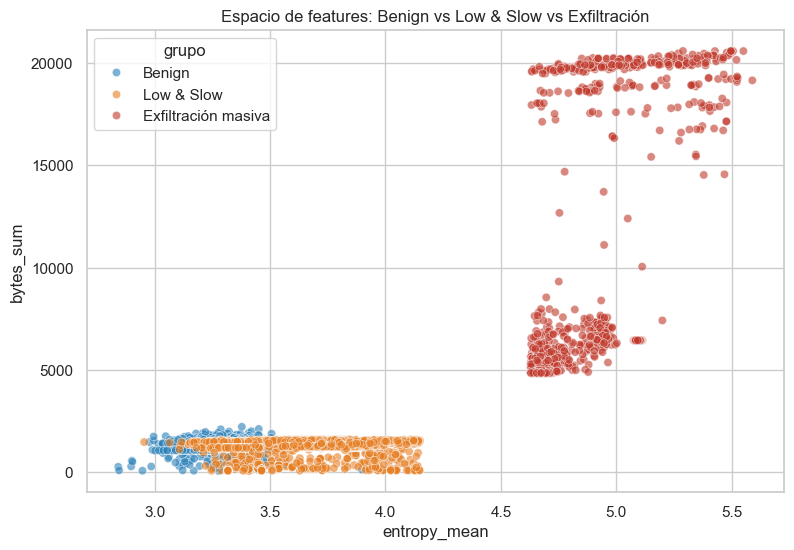

In [29]:
df_viz = pd.concat([
    df_benign.sample(min(2000,len(df_benign)), random_state=42).assign(grupo='Benign'),
    df_low_slow.assign(grupo='Low & Slow'),
    df_exfil.sample(min(len(df_exfil),2000), random_state=42).assign(grupo='Exfiltración masiva'),
]).reset_index(drop=True)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_viz, x='entropy_mean', y='bytes_sum', hue='grupo', palette=['#2980b9','#e67e22','#c0392b'], alpha=0.6)
plt.title('Espacio de features: Benign vs Low & Slow vs Exfiltración')
plt.show()

## 6. Recomendaciones para Preprocesamiento y Modelado

### 6.1 Preprocesamiento previo al entrenamiento

| Paso | Acción | Justificación |
|---|---|---|
| Deduplicación | Eliminar 19,474 filas duplicadas (6.7%) | Evitar data leakage y sesgo de métricas |
| Eliminar `bytes_mean` | Conservar solo `bytes_sum` | Colinealidad con `bytes_sum` (r=0.960); `packet_count` casi constante |
| Transformar IATs | Aplicar `log1p` a `iat_mean` e `iat_std` | Skewness extrema; comprime la cola larga sin perder la resolución en milisegundos |
| Evaluar `iat_mean` post-entrenamiento | Comparar feature importance con y sin la feature | Correlación individual baja (r=0.027) pero posibles interacciones útiles |

### 6.2 Justificación de la arquitectura L1 + L2

| Feature | r con label | Rol en L1 |
|---|---|---|
| `entropy_mean` | 0.957 | Predictor primario — separa la mayoría de ataques |
| `entropy_std` | 0.725 | Complementa la media — capta variabilidad intra-ventana |
| `bytes_sum` | 0.606 | Detecta exfiltración masiva |
| `iat_std` | 0.071 | Débil en aislamiento — señal de automatización C2 en combinación |
| `iat_mean` | 0.027 | Candidato a eliminación; evaluar con feature importance |

Los ataques Low & Slow operan deliberadamente en la zona de baja entropía donde L1 es más débil. 
El Transformer L2 actúa como segunda línea de defensa al analizar la estructura secuencial de los nombres de dominio, 
independientemente del volumen o la entropía agregada.

### 6.3 Reglas operacionales para el SOC

- **Alerta L1 rápida:** `entropy_mean > 4.5` — alta certeza de tunelización, no requiere L2.
- **Cola L2:** `entropy_mean < 3.0` con `iat_std < 0.01` — candidatos a ataques Low & Slow.
- **Deduplicación en producción:** Implementar caché de hashes de ventana para reducir ~7% de carga de inferencia repetida.